In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import joblib


In [2]:
df = pd.read_csv("../data/sigiriya_weather.csv")
df.head()


,dt,dt_iso,timezone,city_name,lat,lon,temp,visibility,dew_point,feels_like,...,wind_gust,rain_1h,rain_3h,snow_1h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,1451606400,2016-01-01 00:00:00 +0000 UTC,19800,Sigiriya,7.945563,80.761577,23.00,NaN,22.16,23.84,...,NaN,0.44,NaN,NaN,NaN,99,500,Rain,light rain,10n
1,1451610000,2016-01-01 01:00:00 +0000 UTC,19800,Sigiriya,7.945563,80.761577,23.11,NaN,22.26,23.96,...,NaN,0.17,NaN,NaN,NaN,100,500,Rain,light rain,10d
2,1451613600,2016-01-01 02:00:00 +0000 UTC,19800,Sigiriya,7.945563,80.761577,23.89,NaN,22.51,24.74,...,NaN,0.11,NaN,NaN,NaN,83,500,Rain,light rain,10d
3,1451617200,2016-01-01 03:00:00 +0000 UTC,19800,Sigiriya,7.945563,80.761577,24.07,NaN,23.39,25.04,...,NaN,NaN,NaN,NaN,NaN,100,804,Clouds,overcast clouds,04d
4,1451620800,2016-01-01 04:00:00 +0000 UTC,19800,Sigiriya,7.945563,80.761577,24.73,NaN,23.16,25.63,...,NaN,NaN,NaN,NaN,NaN,97,804,Clouds,overcast clouds,04d


In [3]:

df['dt_iso'] = pd.to_datetime(df['dt_iso'], format='%Y-%m-%d %H:%M:%S +0000 UTC', errors='coerce')
df = df.sort_values('dt_iso')


In [4]:
df = df[['dt_iso', 'temp', 'rain_1h', 'humidity', 'wind_speed']]


In [5]:
df['rain_1h'] = df['rain_1h'].fillna(0)
df['humidity'] = df['humidity'].fillna(df['humidity'].mean())
df['wind_speed'] = df['wind_speed'].fillna(df['wind_speed'].mean())


In [6]:
df.set_index('dt_iso', inplace=True)

daily = df.resample('D').agg({
    'temp': 'mean',
    'rain_1h': 'sum',
    'humidity': 'mean',
    'wind_speed': 'mean'
})


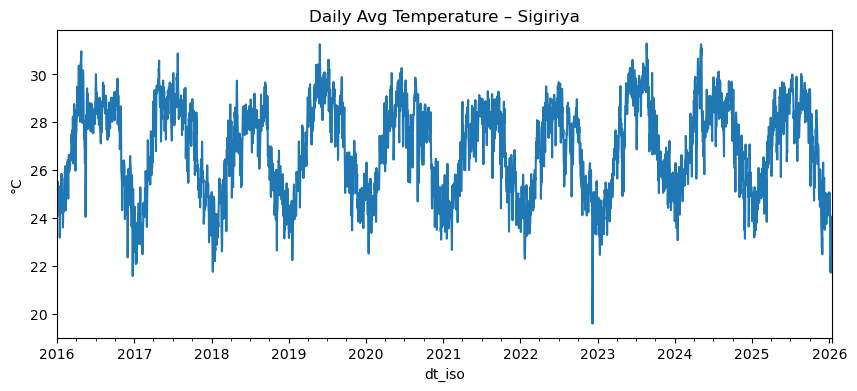

In [7]:
daily['temp'].plot(figsize=(10,4), title="Daily Avg Temperature – Sigiriya")
plt.ylabel("°C")
plt.show()


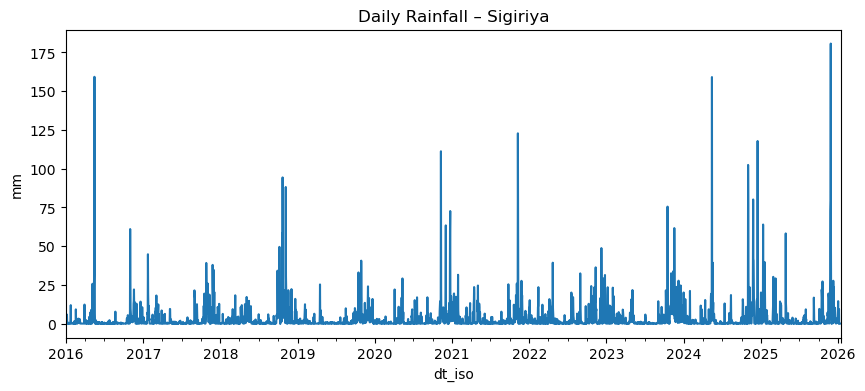

In [8]:
daily['rain_1h'].plot(figsize=(10,4), title="Daily Rainfall – Sigiriya")
plt.ylabel("mm")
plt.show()


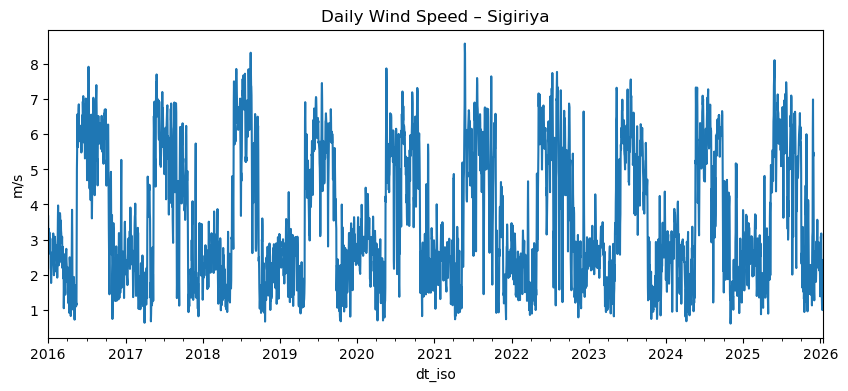

In [9]:
daily['wind_speed'].plot(figsize=(10,4), title="Daily Wind Speed – Sigiriya")
plt.ylabel("m/s")
plt.show()


In [10]:
def sri_lanka_season(month):
    if month in [5,6,7,8,9]:
        return 1   # Southwest Monsoon
    elif month in [12,1,2]:
        return 2   # Northeast Monsoon
    elif month in [3,4]:
        return 3   # First Inter-monsoon
    else:
        return 4   # Second Inter-monsoon


In [11]:
daily['dayofweek'] = daily.index.dayofweek
daily['month'] = daily.index.month
daily['day'] = daily.index.day
daily['season'] = daily.index.month.map(sri_lanka_season)


In [12]:
X = daily[['dayofweek', 'month', 'day', 'season']]

y_temp = daily['temp']
y_rain = daily['rain_1h']
y_wind = daily['wind_speed']


In [13]:
split = int(len(daily) * 0.85)

X_train, X_test = X.iloc[:split], X.iloc[split:]

y_temp_train, y_temp_test = y_temp.iloc[:split], y_temp.iloc[split:]
y_rain_train, y_rain_test = y_rain.iloc[:split], y_rain.iloc[split:]
y_wind_train, y_wind_test = y_wind.iloc[:split], y_wind.iloc[split:]


In [14]:
lr_temp = LinearRegression().fit(X_train, y_temp_train)
lr_rain = LinearRegression().fit(X_train, y_rain_train)
lr_wind = LinearRegression().fit(X_train, y_wind_train)


In [15]:
rf_temp = RandomForestRegressor(n_estimators=200, random_state=42)
rf_temp.fit(X_train, y_temp_train)

rf_rain = RandomForestRegressor(n_estimators=200, random_state=42)
rf_rain.fit(X_train, y_rain_train)

rf_wind = RandomForestRegressor(n_estimators=200, random_state=42)
rf_wind.fit(X_train, y_wind_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
gb_temp = GradientBoostingRegressor().fit(X_train, y_temp_train)
gb_rain = GradientBoostingRegressor().fit(X_train, y_rain_train)
gb_wind = GradientBoostingRegressor().fit(X_train, y_wind_train)


In [17]:
models = {
    "Linear": (lr_temp, lr_rain, lr_wind),
    "RandomForest": (rf_temp, rf_rain, rf_wind),
    "GradientBoost": (gb_temp, gb_rain, gb_wind)
}

for name, (mt, mr, mw) in models.items():
    print(name)
    print("Temp MAE:", mean_absolute_error(y_temp_test, mt.predict(X_test)))
    print("Rain MAE:", mean_absolute_error(y_rain_test, mr.predict(X_test)))
    print("Wind MAE:", mean_absolute_error(y_wind_test, mw.predict(X_test)))
    print("-"*30)


Linear
Temp MAE: 1.402410537100314
Rain MAE: 5.206849603013243
Wind MAE: 1.1927149108366473
------------------------------
RandomForest
Temp MAE: 0.9257750959204762
Rain MAE: 5.992149418121454
Wind MAE: 1.013434330937797
------------------------------
GradientBoost
Temp MAE: 0.7809090877147274
Rain MAE: 5.1700913714888
Wind MAE: 0.8947330494556001
------------------------------


In [18]:
import joblib

joblib.dump(gb_temp, "../models/temp.pkl")
joblib.dump(gb_rain, "../models/rain.pkl")
joblib.dump(gb_wind, "../models/wind.pkl")


['../models/wind.pkl']

In [19]:
future_days = 7

future_dates = pd.date_range(
    start=daily.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)


In [20]:
future_X = pd.DataFrame({
    'dayofweek': future_dates.dayofweek,
    'month': future_dates.month,
    'day': future_dates.day,
    'season': future_dates.month.map(sri_lanka_season)
})


In [21]:
temp_forecast = gb_temp.predict(future_X)
rain_forecast = gb_rain.predict(future_X)
wind_forecast = gb_wind.predict(future_X)


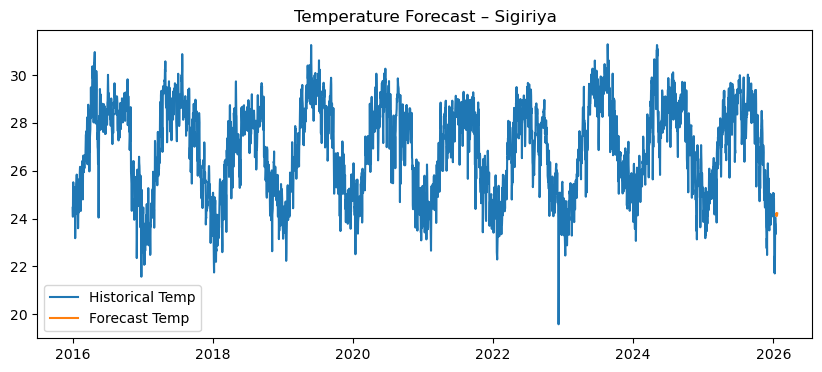

In [22]:
plt.figure(figsize=(10,4))
plt.plot(daily['temp'], label="Historical Temp")
plt.plot(future_dates, temp_forecast, label="Forecast Temp")
plt.legend()
plt.title("Temperature Forecast – Sigiriya")
plt.show()


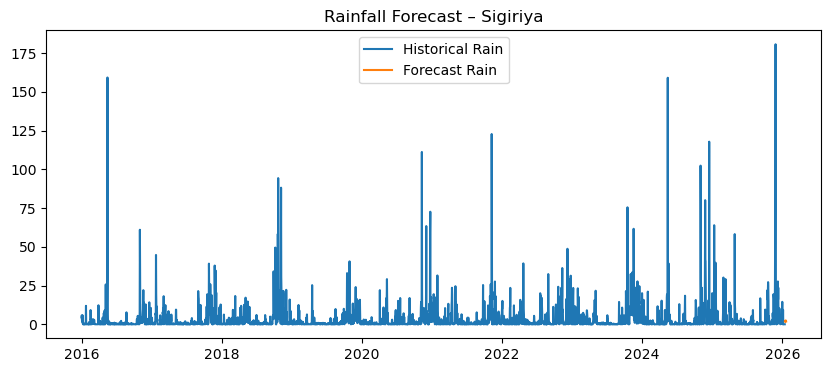

In [23]:
plt.figure(figsize=(10,4))
plt.plot(daily['rain_1h'], label="Historical Rain")
plt.plot(future_dates, rain_forecast, label="Forecast Rain")
plt.legend()
plt.title("Rainfall Forecast – Sigiriya")
plt.show()


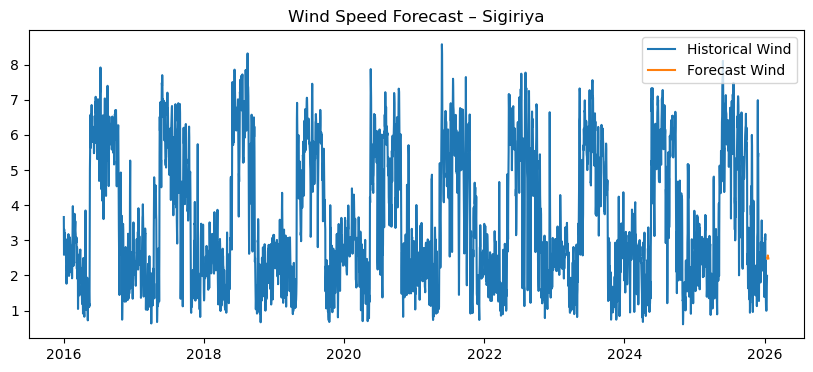

In [24]:
plt.figure(figsize=(10,4))
plt.plot(daily['wind_speed'], label="Historical Wind")
plt.plot(future_dates, wind_forecast, label="Forecast Wind")
plt.legend()
plt.title("Wind Speed Forecast – Sigiriya")
plt.show()


In [25]:
def weather_type(rain, wind):
    if rain > 15:
        return "Heavy Rain 🌧️"
    elif rain > 3:
        return "Light Rain 🌦️"
    elif wind > 5:
        return "Windy 🌬️"
    else:
        return "Clear ☀️"


In [26]:
%reset -f



In [27]:
import joblib

# Load the trained models
temp_model = joblib.load("../models/temp.pkl")  # temperature model
rain_model = joblib.load("../models/rain.pkl")  # rain model
wind_model = joblib.load("../models/wind.pkl")  # wind model


In [28]:
def sri_lanka_season(month):
    if month in [5,6,7,8,9]:
        return 1  # Southwest monsoon
    elif month in [12,1,2]:
        return 2  # Northeast monsoon
    elif month in [3,4]:
        return 3  # Inter-monsoon
    else:
        return 4  # Other

def weather_type(rain, wind):
    if rain > 15:
        return "Heavy Rain 🌧️"
    elif rain > 3:
        return "Light Rain 🌦️"
    elif wind > 5:
        return "Windy 🌬️"
    else:
        return "Clear ☀️"


In [29]:
import pandas as pd

def get_weather_for_dates(dates):
    X = pd.DataFrame({
        'dayofweek': [d.weekday() for d in dates],
        'month': [d.month for d in dates],
        'day': [d.day for d in dates],
        'season': [sri_lanka_season(d.month) for d in dates]
    })

    temps = temp_model.predict(X)
    rains = rain_model.predict(X)
    winds = wind_model.predict(X)

    response = ""
    for i, d in enumerate(dates):
        response += (
            f"{d.date()} (Day {i+1}): "
            f"{round(temps[i],1)}°C, "
            f"{weather_type(rains[i], winds[i])}, "
            f"Wind {round(winds[i],1)} m/s\n"
        )
    return response.strip()
